In [60]:


import pandas as pd
import matplotlib.pyplot as plt
import os
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from pathlib import Path
import sys
from data_registry import datasets
from scipy.ndimage import uniform_filter1d
import statsmodels.formula.api as smf

from utils import mainutil
# os.getcwd()
# os.chdir(r"C:\Users\ryanc\repo\Time-Series-Analysis-Project")
    

In [3]:
cwd = Path.cwd()
cwd

WindowsPath('c:/Users/floydry/repos/Time-Series-Analysis-Project/homework')

# Plot and Exploratory Analysis

*Read data*

In [4]:
cwd.parent

WindowsPath('c:/Users/floydry/repos/Time-Series-Analysis-Project')

In [50]:

snow_data = pd.read_csv('BogusSnowDaily.csv')
snow_data.columns = (['Date', 'Depth'])


snow_data['Date'] = pd.to_datetime(snow_data['Date'])
snow_data.set_index('Date',drop=True, inplace=True)

snow_data_monthly = snow_data.resample("ME").mean()

snow_daily = mainutil.to_ts(snow_data['Depth'], snow_data.index)
snow_monthly = mainutil.to_ts(snow_data_monthly['Depth'], snow_data_monthly.index)

print(snow_monthly.head())
print(snow_daily.head())



                   ts       pts
Date                           
1999-09-30   0.000000  0.000000
1999-10-31   0.000000  0.003236
1999-11-30   2.700000  0.006472
1999-12-31  22.580645  0.009709
2000-01-31  57.032258  0.012945
            ts       pts
Date                    
1999-09-23   0  0.000000
1999-09-24   0  0.000106
1999-09-25   0  0.000213
1999-09-26   0  0.000319
1999-09-27   0  0.000425


In [6]:
from plots.ts_plot import ts_plot
from plots.residual_plot import residual_plot

C:\Users\floydry\AppData\Local\Temp\ipykernel_18640\3874094955.py:10: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


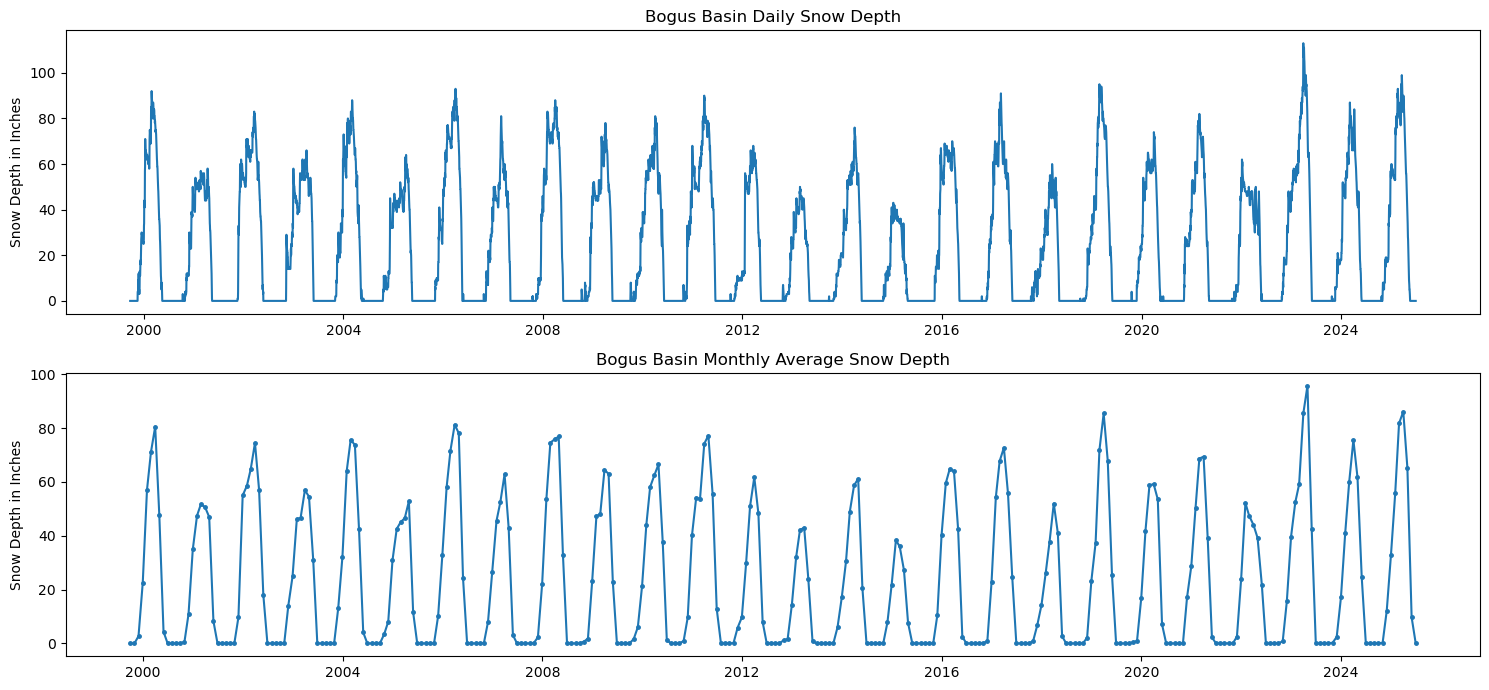

In [53]:
fig, axs = plt.subplots(2,1, figsize=(15,7))
axs[0].plot(snow_daily['ts'])
axs[0].set_title('Bogus Basin Daily Snow Depth')
axs[0].set_ylabel("Snow Depth in Inches")

axs[1].plot(snow_monthly['ts'], marker = '.', markersize = 5  )
axs[1].set_title('Bogus Basin Monthly Average Snow Depth')
axs[1].set_ylabel("Snow Depth in Inches")
fig.tight_layout()
fig.show()

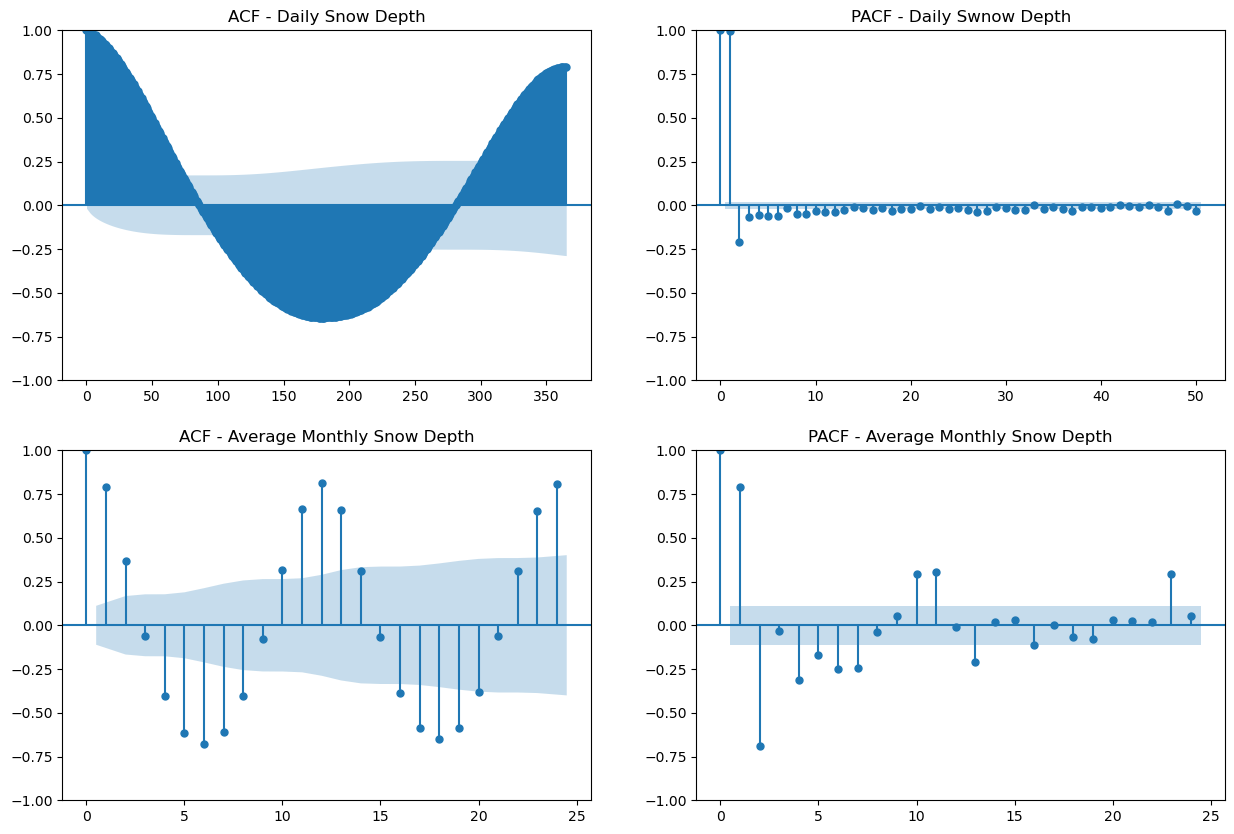

In [55]:
fig, axs = plt.subplots(2,2, figsize = (15,10))
plot_acf(snow_daily['ts'], lags = 365, ax = axs[0,0], title = 'ACF - Daily Snow Depth');
plot_pacf(snow_daily['ts'], lags = 50, ax = axs[0,1], title = "PACF - Daily Swnow Depth");

plot_acf(snow_monthly['ts'], lags = 24, ax = axs[1,0], title  = "ACF - Average Monthly Snow Depth");
plot_pacf(snow_monthly['ts'], lags = 24, ax = axs[1,1], title = 'PACF - Average Monthly Snow Depth');

# Moving Average with Seasonal Anova


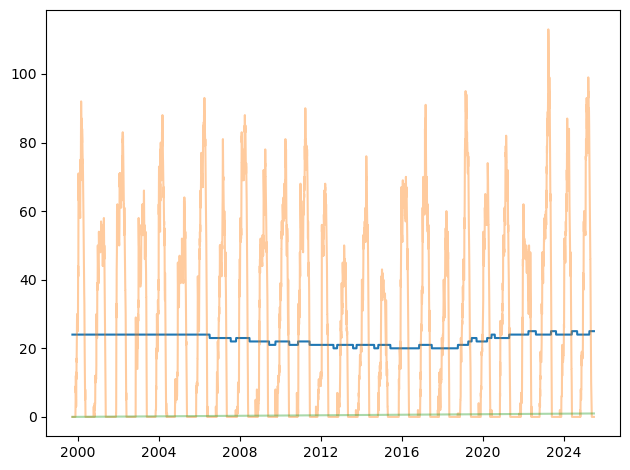

In [57]:
mavModel = uniform_filter1d(snow_daily['ts'], size=len(snow_daily['ts'])//2)
mavModel
mav_data = pd.Series(mavModel, index=snow_daily.index)
plt.plot(mav_data)
plt.plot(snow_daily, alpha =.4)
plt.tight_layout()

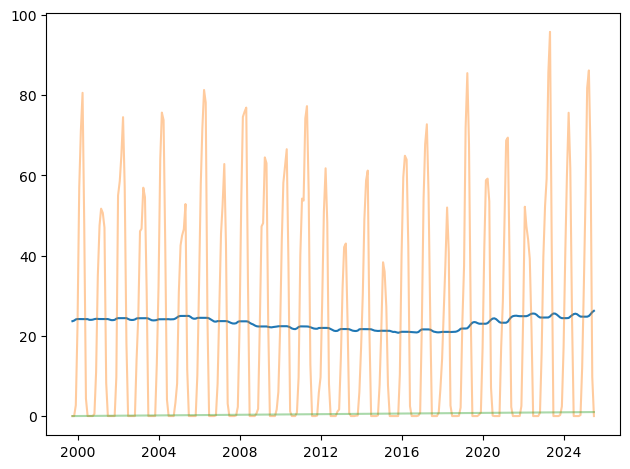

In [58]:
monthly_mavModel = uniform_filter1d(snow_monthly['ts'], size=len(snow_monthly['ts'])//2)

monthly_mav_data = pd.Series(monthly_mavModel, index=snow_monthly.index)
plt.plot(monthly_mav_data)
plt.plot(snow_monthly, alpha =.4)
plt.tight_layout()

Date
1999-09-23    38
1999-09-24    38
1999-09-25    38
1999-09-26    38
1999-09-27    39
              ..
2025-06-26    26
2025-06-27    26
2025-06-28    26
2025-06-29    26
2025-06-30    27
Name: week, Length: 9411, dtype: UInt32

In [74]:
snow_daily_seasonal = snow_daily.copy()
snow_daily_seasonal['month'] = snow_daily_seasonal.index.month
snow_daily_seasonal['week'] = snow_daily_seasonal.index.isocalendar().week.astype('float')

seasonalmodel = smf.ols(formula = 'ts~C(week)-1', data = snow_daily_seasonal).fit()
seasonalmodel.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                     ts   R-squared:                       0.847
Model:                            OLS   Adj. R-squared:                  0.847
Method:                 Least Squares   F-statistic:                     999.6
Date:                Mon, 20 Apr 2026   Prob (F-statistic):               0.00
Time:                        19:35:31   Log-Likelihood:                -35688.
No. Observations:                9411   AIC:                         7.148e+04
Df Residuals:                    9358   BIC:                         7.186e+04
Df Model:                          52                                         
Covariance Type:            nonrobust                                         
=================================================================================
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
C(week)[1.0]     41.0714      0.798     51.482      0.000      39.508      42.635
C(week)[2.0]     45.9231      0.798     57.564      0.000      44.359      47.487
C(week)[3.0]     48.7857      0.798     61.152      0.000      47.222      50.350
C(week)[4.0]     50.3516      0.798     63.115      0.000      48.788      51.915
C(week)[5.0]     52.4176      0.798     65.705      0.000      50.854      53.981
C(week)[6.0]     54.6209      0.798     68.467      0.000      53.057      56.185
C(week)[7.0]     57.4725      0.798     72.041      0.000      55.909      59.036
C(week)[8.0]     61.7912      0.798     77.454      0.000      60.227      63.355
C(week)[9.0]     64.3736      0.798     80.691      0.000      62.810      65.937
C(week)[10.0]    65.2802      0.798     81.828      0.000      63.716      66.844
C(week)[11.0]    65.1099      0.798     81.614      0.000      63.546      66.674
C(week)[12.0]    64.6923      0.798     81.091      0.000      63.128      66.256
C(week)[13.0]    65.0879      0.798     81.587      0.000      63.524      66.652
C(week)[14.0]    63.1978      0.798     79.218      0.000      61.634      64.762
C(week)[15.0]    59.0714      0.798     74.045      0.000      57.508      60.635
C(week)[16.0]    52.0934      0.798     65.298      0.000      50.530      53.657
C(week)[17.0]    44.2308      0.798     55.443      0.000      42.667      45.795
C(week)[18.0]    34.3956      0.798     43.114      0.000      32.832      35.959
C(week)[19.0]    25.2088      0.798     31.599      0.000      23.645      26.773
C(week)[20.0]    14.7912      0.798     18.541      0.000      13.227      16.355
C(week)[21.0]     7.2308      0.798      9.064      0.000       5.667       8.795
C(week)[22.0]     2.1978      0.798      2.755      0.006       0.634       3.762
C(week)[23.0]     0.9337      0.800      1.167      0.243      -0.634       2.502
C(week)[24.0]     0.1593      0.798      0.200      0.842      -1.404       1.723
C(week)[25.0]          0      0.798          0      1.000      -1.564       1.564
C(week)[26.0]          0      0.798          0      1.000      -1.564       1.564
C(week)[27.0]          0      0.811          0      1.000      -1.590       1.590
C(week)[28.0]          0      0.814          0      1.000      -1.595       1.595
C(week)[29.0]          0      0.814          0      1.000      -1.595       1.595
C(week)[30.0]          0      0.814          0      1.000      -1.595       1.595
C(week)[31.0]          0      0.814          0      1.000      -1.595       1.595
C(week)[32.0]          0      0.814          0      1.000      -1.595       1.595
C(week)[33.0]          0      0.814          0      1.000      -1.595       1.595
C(week)[34.0]          0      0.814          0      1.000      -1.595       1.595
C(week)[35.0]          0      0.814          0   

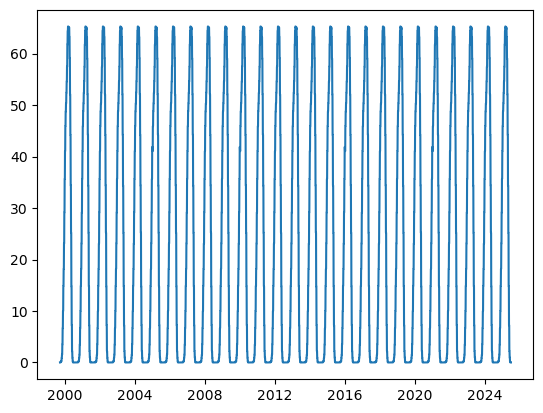

In [78]:
plt.plot(seasonalmodel.fittedvalues)

#plt.plot(seasonalmodel.params)